# HR Attrition AI — Retention Decision-Support System

**Goal**: Predict which active employees are at voluntary resignation risk, explain why, and suggest preventive HR actions.

**Responsible AI constraints**:
- No protected attributes (`Sex`, `RaceDesc`, `HispanicLatino`) as model features
- All direct identifiers removed before modeling
- No outcome-leakage fields used in training
- Fairness audit conducted separately on sensitive groups

---
## Section 0 — Setup & Imports

In [1]:
# All packages are pre-installed in the virtual environment
# No need to pip install — this avoids hangs during import
print("✓ Environment ready. All dependencies pre-installed.")

✓ Environment ready. All dependencies pre-installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from collections import Counter

# NLP
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap
shap.initjs()

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')

TODAY = datetime.today()
RANDOM_STATE = 42
print('Setup complete. Today:', TODAY.date())

Setup complete. Today: 2026-03-17


---
## Section 1 — Data Loading & Filtering

In [3]:
# Load the dataset from your local workspace
# (Google Colab file upload not available in local VS Code environment)
import os
DATA_FILE = 'HRDataset_v14_enriched.csv'
if not os.path.exists(DATA_FILE):
    print(f'Error: {DATA_FILE} not found in current directory')
    print('Available CSV files:', [f for f in os.listdir('.') if f.endswith('.csv')])
else:
    print(f'✓ {DATA_FILE} found')

✓ HRDataset_v14_enriched.csv found


In [4]:
df_raw = pd.read_csv('HRDataset_v14_enriched.csv')
print(f'Raw shape: {df_raw.shape}')
print('\nEmploymentStatus distribution:')
print(df_raw['EmploymentStatus'].value_counts())

Raw shape: (311, 38)

EmploymentStatus distribution:
EmploymentStatus
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64


In [5]:
# Filter: keep only Active and Voluntarily Terminated (exclude Terminated for Cause)
VALID_STATUSES = ['Active', 'Voluntarily Terminated']
df = df_raw[df_raw['EmploymentStatus'].isin(VALID_STATUSES)].copy()
print(f'After filter: {df.shape[0]} rows ({df_raw.shape[0] - df.shape[0]} "Terminated for Cause" dropped)')

# Binary target
df['target'] = (df['EmploymentStatus'] == 'Voluntarily Terminated').astype(int)
print('\nTarget distribution:')
print(df['target'].value_counts().rename({0: 'Active', 1: 'Voluntarily Terminated'}))

After filter: 295 rows (16 "Terminated for Cause" dropped)

Target distribution:
target
Active                    207
Voluntarily Terminated     88
Name: count, dtype: int64


---
## Section 2 — Privacy & Data Cleaning

### 2a. Separate sensitive attributes (fairness audit use only)

In [6]:
# Keep sensitive attributes in a separate dataframe for fairness audit
# These are NEVER passed to the model
SENSITIVE_COLS = ['Sex', 'RaceDesc', 'HispanicLatino']
df_fairness = df[SENSITIVE_COLS + ['target']].copy()
print('Fairness audit df shape:', df_fairness.shape)
print('\nSex distribution:')
print(df_fairness['Sex'].value_counts())
print('\nRaceDesc distribution:')
print(df_fairness['RaceDesc'].value_counts())

Fairness audit df shape: (295, 4)

Sex distribution:
Sex
F     167
M     128
Name: count, dtype: int64

RaceDesc distribution:
RaceDesc
White                               178
Black or African American            74
Asian                                29
Two or more races                    10
American Indian or Alaska Native      3
Hispanic                              1
Name: count, dtype: int64


### 2b. Remove direct identifiers and leakage fields

In [8]:
# Direct identifiers — removed for privacy
IDENTIFIERS = ['Employee_Name', 'EmpID', 'ManagerName', 'ManagerID']

# Outcome leakage — would reveal the answer at training time
# Note: DateofTermination is intentionally excluded here.
# It is needed in Section 3 to compute actual tenure for terminated employees,
# then dropped immediately after. It is never used as a model feature.
LEAKAGE = ['Termd', 'TermReason', 'EmploymentStatus', 'EmpStatusID']

# Protected attributes — kept only in df_fairness
PROTECTED = ['Sex', 'RaceDesc', 'HispanicLatino']

# Redundant ID columns (replaced by text equivalents)
REDUNDANT_IDS = ['MarriedID', 'MaritalStatusID', 'GenderID', 'DeptID',
                 'PositionID', 'PerfScoreID', 'FromDiversityJobFairID']

COLS_TO_DROP = IDENTIFIERS + LEAKAGE + PROTECTED + REDUNDANT_IDS
df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
print(f'Columns after drop: {df.shape[1]}')
print('Remaining columns:', df.columns.tolist())

Columns after drop: 21
Remaining columns: ['Salary', 'Position', 'State', 'Zip', 'DOB', 'MaritalDesc', 'CitizenDesc', 'DateofHire', 'DateofTermination', 'Department', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences', 'Internal_Transfer_Request', 'Feedback_RH', 'target']


---
## Section 3 — Structured Feature Engineering

In [9]:
# --- Reference date ---
# The dataset was collected around January 2019 — evidence: all active employees
# received their LastPerformanceReview_Date within a 57-day window (std = 16 days).
# Computing temporal features from TODAY (2026-03-16) introduces two leakages:
#   1. tenure_years inflated by 7 extra years for active employees vs actual
#      tenure of terminated employees — single-feature AUC ≈ 1.0
#   2. days_since_review is constant for all active employees (std = 16 days)
#      and much larger for terminated employees (reviews from 5–12 years ago)
#      — single-feature AUC = 1.0
# Anchoring to REF_DATE fixes both issues.
REF_DATE = pd.Timestamp('2019-01-01')

# --- Date features ---
# DOB uses 2-digit years (MM/DD/YY); DateofHire uses 4-digit years (M/D/YYYY)
df['DOB'] = pd.to_datetime(df['DOB'], format='%m/%d/%y', errors='coerce')
# Pandas maps 2-digit years 00-68 → 2000-2068, so anyone born before ~1969
# gets pushed 100 years into the future — correct those back
future_dob_mask = df['DOB'] > TODAY
df.loc[future_dob_mask, 'DOB'] = df.loc[future_dob_mask, 'DOB'] - pd.DateOffset(years=100)

df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

# Age: anchored to REF_DATE to avoid 7-year inflation from running in 2026
df['age'] = ((REF_DATE - df['DOB']).dt.days / 365.25).round(1)

# Tenure: actual tenure for terminated employees (hire → termination),
# snapshot tenure for active employees (hire → data collection date).
# Using TODAY for active employees would inflate tenure by 7+ years beyond
# the data collection date, creating near-perfect target separation (AUC ≈ 1.0).
# DateofTermination is used here for correct computation — NOT as a feature.
df['tenure_years'] = np.where(
    df['target'] == 1,
    (df['DateofTermination'] - df['DateofHire']).dt.days / 365.25,
    (REF_DATE - df['DateofHire']).dt.days / 365.25
).round(2)

# days_since_review is EXCLUDED:
# All active employees share the same review cycle (std = 16 days → near-zero
# variance). This makes the feature useless for ranking active employees AND
# a perfect separator in training (AUC = 1.0). It encodes termination status,
# not a genuine HR signal.

# Drop raw date columns (DateofTermination used above — now also dropped)
df = df.drop(columns=['DOB', 'DateofHire', 'LastPerformanceReview_Date',
                      'DateofTermination'], errors='ignore')

# Drop quasi-identifiers with low business value
df = df.drop(columns=[c for c in ['Zip', 'State'] if c in df.columns])

# --- Relative salary ---
dept_mean_salary = df.groupby('Department')['Salary'].transform('mean')
df['salary_vs_dept_mean'] = (df['Salary'] / dept_mean_salary).round(4)

# --- Composite engagement score ---
df['engagement_x_satisfaction'] = df['EngagementSurvey'] * df['EmpSatisfaction']

print('New engineered features: age, tenure_years, salary_vs_dept_mean, engagement_x_satisfaction')
print(f'Age range: {df["age"].min():.1f} – {df["age"].max():.1f}  (mean: {df["age"].mean():.1f})')
print(f'Tenure range: {df["tenure_years"].min():.1f} – {df["tenure_years"].max():.1f}  (mean: {df["tenure_years"].mean():.1f})')
df[['age', 'tenure_years', 'salary_vs_dept_mean', 'engagement_x_satisfaction']].describe()

New engineered features: age, tenure_years, salary_vs_dept_mean, engagement_x_satisfaction
Age range: 26.4 – 68.0  (mean: 40.0)
Tenure range: 0.1 – 13.0  (mean: 4.8)


,age,tenure_years,salary_vs_dept_mean,engagement_x_satisfaction
count,295.000000,295.000000,295.000000,295.000000
mean,39.981695,4.793424,0.999997,16.246746
std,8.972396,2.141916,0.237833,4.976835
min,26.400000,0.070000,0.523300,2.240000
25%,32.600000,3.680000,0.879350,12.900000
50%,38.400000,4.640000,0.976500,16.250000
75%,45.100000,6.210000,1.068400,20.000000
max,68.000000,12.980000,2.844700,25.000000


In [10]:
# Encode categorical features
CATEGORICAL_COLS = ['Department', 'Position', 'MaritalDesc', 'CitizenDesc',
                    'RecruitmentSource', 'PerformanceScore']

label_encoders = {}
for col in CATEGORICAL_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print('Categorical columns encoded:', CATEGORICAL_COLS)

Categorical columns encoded: ['Department', 'Position', 'MaritalDesc', 'CitizenDesc', 'RecruitmentSource', 'PerformanceScore']


---
## Section 4 — NLP Feature Engineering

Text fields are used **only** to derive numeric signals. No raw text enters the model.

In [11]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    """Return VADER compound score for text, 0.0 if empty."""
    if pd.isna(text) or str(text).strip() == '':
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

def keyword_flag(text, keywords):
    """Return 1 if any keyword found in lowercased text."""
    if pd.isna(text) or str(text).strip() == '':
        return 0
    t = str(text).lower()
    return int(any(kw in t for kw in keywords))

# --- Transfer request features ---
df['has_transfer_request'] = df['Internal_Transfer_Request'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1
)
df['transfer_request_sentiment'] = df['Internal_Transfer_Request'].apply(vader_score)

# --- Feedback features ---
df['has_feedback'] = df['Feedback_RH'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1
)
df['feedback_sentiment'] = df['Feedback_RH'].apply(vader_score)

DEPARTURE_KWS = ['leaving', 'quit', 'resign', 'move on', 'other opportunity',
                 'new job', 'departure', 'accepted', 'i have decided to leave']
df['feedback_has_departure_intent'] = df['Feedback_RH'].apply(
    lambda x: keyword_flag(x, DEPARTURE_KWS)
)

# --- EDA-only keyword flags ---
COMPENSATION_KWS = ['salary', 'pay', 'compensation', 'underpaid', 'raise', 'wage']
GROWTH_KWS       = ['career', 'promotion', 'growth', 'development', 'opportunity', 'advance']
WORKLOAD_KWS     = ['burnout', 'overload', 'hours', 'stress', 'schedule', 'overtime', 'workload']
MANAGEMENT_KWS   = ['manager', 'leadership', 'unfair', 'micromanage', 'supervisor', 'boss']

df['feedback_has_compensation'] = df['Feedback_RH'].apply(lambda x: keyword_flag(x, COMPENSATION_KWS))
df['feedback_has_growth']       = df['Feedback_RH'].apply(lambda x: keyword_flag(x, GROWTH_KWS))
df['feedback_has_workload']     = df['Feedback_RH'].apply(lambda x: keyword_flag(x, WORKLOAD_KWS))
df['feedback_has_management']   = df['Feedback_RH'].apply(lambda x: keyword_flag(x, MANAGEMENT_KWS))

# --- NLP feature classification ---
# ALL NLP features are excluded from the model.
# Both text fields are synthetic — the data generation process created transfer requests
# and feedback preferentially for employees who ended up leaving, causing structural leakage
# in BOTH fields (not just Feedback_RH). The model achieves AUC=1.0 through these shortcuts.
#
# Resolution: NLP features are used ONLY as advisory overlays in the risk report (Section 9)
# and for EDA. The model trains exclusively on structured HR features.
NLP_FEATURES  = []   # nothing goes into the model from NLP

NLP_ADVISORY  = ['has_transfer_request', 'transfer_request_sentiment',
                 'has_feedback', 'feedback_sentiment', 'feedback_has_departure_intent']

NLP_EDA_FLAGS = ['feedback_has_compensation', 'feedback_has_growth',
                 'feedback_has_workload', 'feedback_has_management']

print('NLP model features (excluded — all advisory):', NLP_FEATURES)
print('NLP advisory overlay:', NLP_ADVISORY)
print('NLP EDA-only:', NLP_EDA_FLAGS)
df[NLP_ADVISORY].describe().round(3)

NLP model features (excluded — all advisory): []
NLP advisory overlay: ['has_transfer_request', 'transfer_request_sentiment', 'has_feedback', 'feedback_sentiment', 'feedback_has_departure_intent']
NLP EDA-only: ['feedback_has_compensation', 'feedback_has_growth', 'feedback_has_workload', 'feedback_has_management']


,has_transfer_request,transfer_request_sentiment,has_feedback,feedback_sentiment,feedback_has_departure_intent
count,295.000,295.000,295.000,295.000,295.000
mean,0.244,0.184,0.549,0.319,0.136
std,0.430,0.334,0.498,0.446,0.343
min,0.000,0.000,0.000,-0.840,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,1.000,0.000,0.000
75%,0.000,0.000,1.000,0.744,0.000
max,1.000,0.914,1.000,0.952,1.000


In [12]:
# Drop raw text columns — not used in model
# Keep EDA keyword flags in df until after Section 5, then they'll be excluded
# from FEATURE_COLS automatically (they're in NLP_EDA_FLAGS, not NLP_FEATURES)
df = df.drop(columns=['Internal_Transfer_Request', 'Feedback_RH'], errors='ignore')
print(f'Final df shape: {df.shape}')

Final df shape: (295, 32)


---
## Section 5 — Exploratory Data Analysis (EDA)

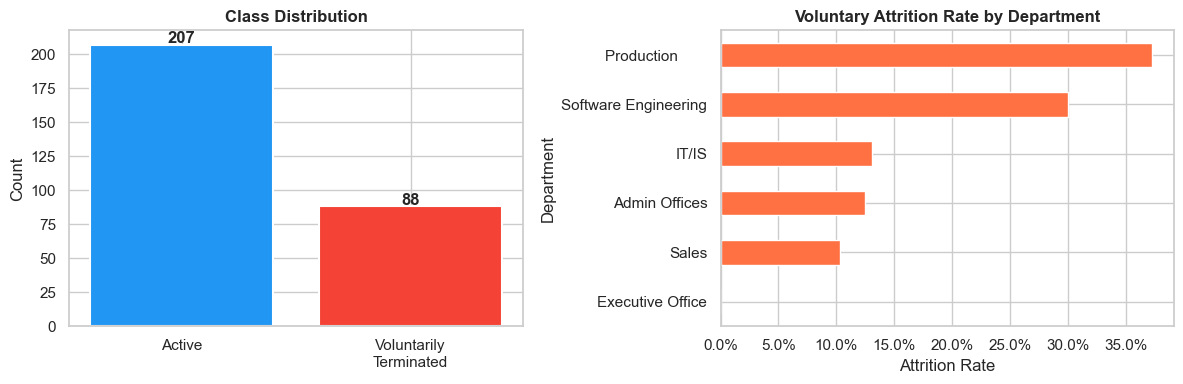

In [13]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts().rename({0: 'Active', 1: 'Voluntarily\nTerminated'})
axes[0].bar(counts.index, counts.values, color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Attrition rate by Department
dept_attr = df.groupby('Department')['target'].mean().sort_values(ascending=True)
dept_attr.plot(kind='barh', ax=axes[1], color='#FF7043')
axes[1].set_title('Voluntary Attrition Rate by Department', fontweight='bold')
axes[1].set_xlabel('Attrition Rate')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

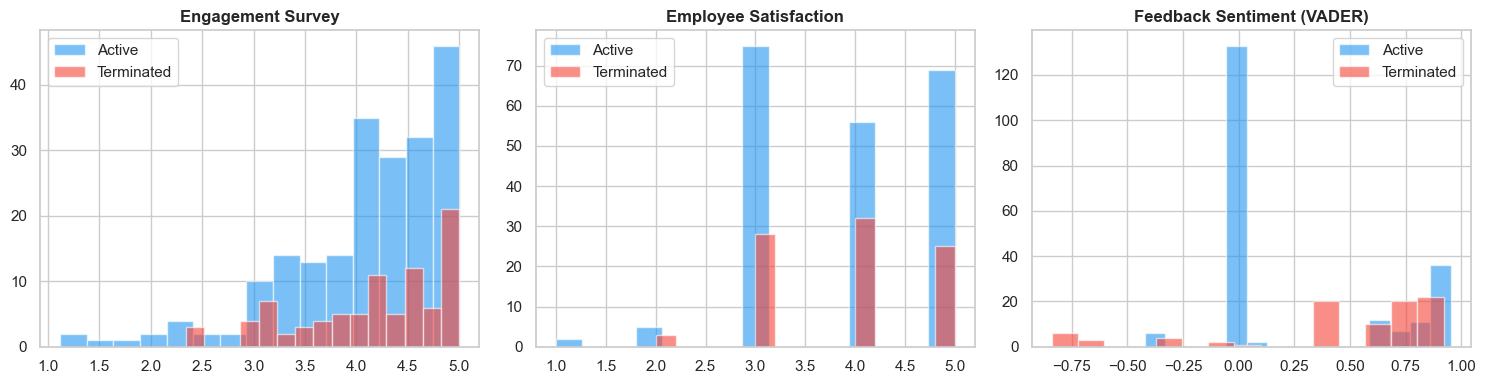

In [14]:
# Engagement & Satisfaction distributions by target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['EngagementSurvey', 'EmpSatisfaction', 'feedback_sentiment'],
    ['Engagement Survey', 'Employee Satisfaction', 'Feedback Sentiment (VADER)']):
    for val, label, color in [(0, 'Active', '#2196F3'), (1, 'Terminated', '#F44336')]:
        subset = df[df['target'] == val][col].dropna()
        ax.hist(subset, bins=15, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

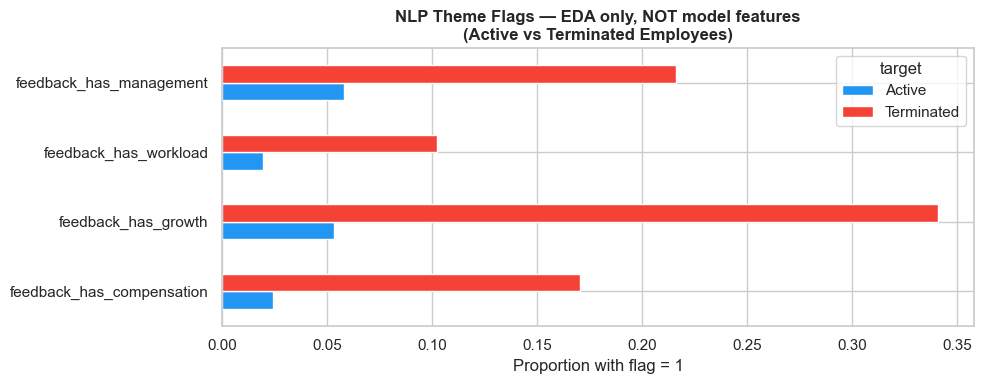

target                     Active  Terminated
feedback_has_compensation   0.024       0.170
feedback_has_growth         0.053       0.341
feedback_has_workload       0.019       0.102
feedback_has_management     0.058       0.216

Note: feedback_has_growth shows 6.4x lift (5% active vs 34% terminated)
but this reflects exit interview language, not predictive risk for active employees.


In [15]:
# NLP theme flags: % of Active vs Terminated employees with each flag
# NOTE: these are shown for EDA insight only — they are NOT used as model features
# (see Section 4 comments for why feedback keyword flags were excluded)
flag_cols = NLP_EDA_FLAGS

nlp_summary = df.groupby('target')[flag_cols].mean().T.rename(columns={0: 'Active', 1: 'Terminated'})
nlp_summary.plot(kind='barh', figsize=(10, 4), color=['#2196F3', '#F44336'])
plt.title('NLP Theme Flags — EDA only, NOT model features\n(Active vs Terminated Employees)', fontweight='bold')
plt.xlabel('Proportion with flag = 1')
plt.tight_layout()
plt.show()
print(nlp_summary.round(3))
print('\nNote: feedback_has_growth shows 6.4x lift (5% active vs 34% terminated)')
print('but this reflects exit interview language, not predictive risk for active employees.')

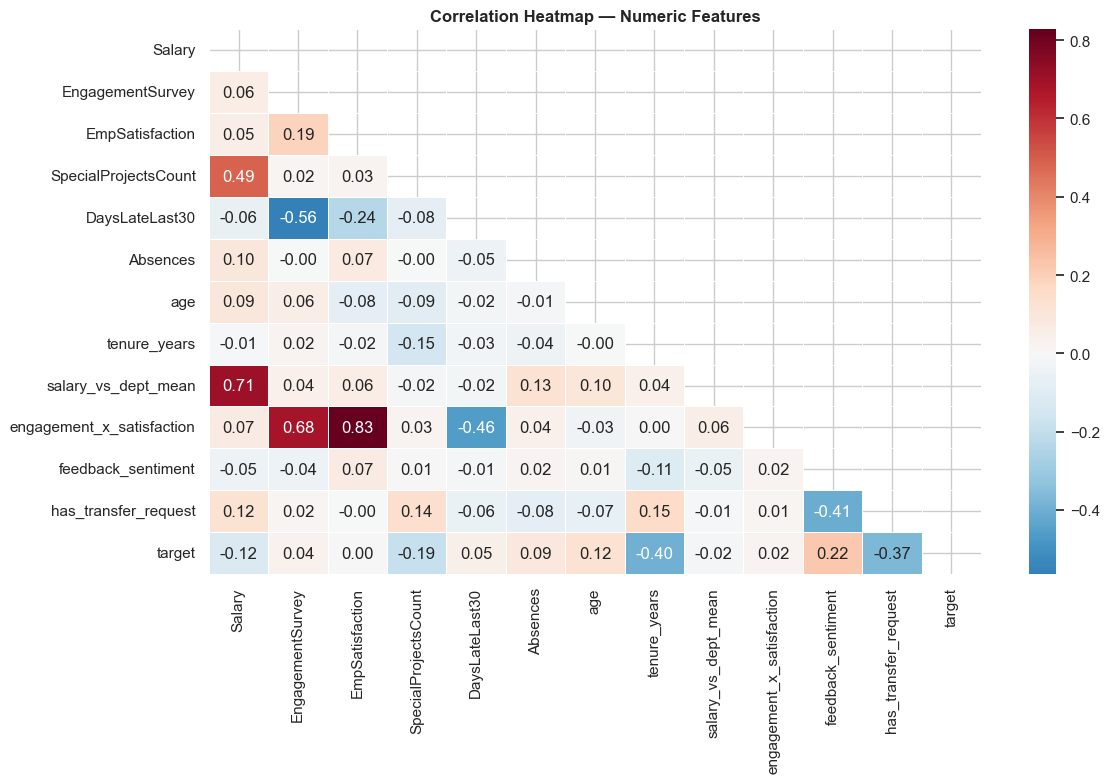

In [16]:
# Correlation heatmap (numeric features)
NUMERIC_COLS = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
                'DaysLateLast30', 'Absences', 'age', 'tenure_years',
                'salary_vs_dept_mean', 'engagement_x_satisfaction',
                'feedback_sentiment', 'has_transfer_request', 'target']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df.columns]

plt.figure(figsize=(12, 8))
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=False)
plt.title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6 — Modeling

In [17]:
# Build modeling feature set
# Exclude: original categorical text cols (replaced by _enc), target,
#          NLP EDA flags (semantically ambiguous keyword flags),
#          NLP advisory features (feedback contamination — see Section 4)
NON_FEATURE_COLS = ['target'] + CATEGORICAL_COLS + NLP_EDA_FLAGS + NLP_ADVISORY
FEATURE_COLS = [c for c in df.columns
                if c not in NON_FEATURE_COLS
                and c != 'target'
                and pd.api.types.is_numeric_dtype(df[c])]

print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Total features: 16
['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'age', 'tenure_years', 'salary_vs_dept_mean', 'engagement_x_satisfaction', 'Department_enc', 'Position_enc', 'MaritalDesc_enc', 'CitizenDesc_enc', 'RecruitmentSource_enc', 'PerformanceScore_enc']


In [19]:
X = df[FEATURE_COLS].copy()
y = df['target'].copy()

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train attrition rate: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Train: 236 rows | Test: 59 rows
Train attrition rate: 29.7% | Test: 30.5%


In [21]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only — synthesises minority-class samples
# to complement class_weight='balanced'. Test set and active employees are NEVER touched.
X_train_sm, y_train_sm = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
print(f'Original train — {X_train.shape[0]} rows | Attrition: {y_train.mean():.1%}')
print(f'After SMOTE  — {X_train_sm.shape[0]} rows | Attrition: {y_train_sm.mean():.1%}')

Original train — 236 rows | Attrition: 29.7%
After SMOTE  — 332 rows | Attrition: 50.0%


In [22]:
# --- Model 1: Logistic Regression (baseline) ---
scaler = StandardScaler()
X_train_sm_sc = scaler.fit_transform(X_train_sm)   # fit on SMOTE-augmented train
X_test_sc     = scaler.transform(X_test)            # transform test (never augmented)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sm_sc, y_train_sm)

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

# --- Model 3: XGBoost ---
# scale_pos_weight ~1.0 after SMOTE (classes already balanced), but recalculate for safety
scale_pos = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()
xgb = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos,
                    random_state=RANDOM_STATE, eval_metric='logloss',
                    n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)

print('Models trained: Logistic Regression, Random Forest, XGBoost')

Models trained: Logistic Regression, Random Forest, XGBoost


In [23]:
# Evaluation
models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb, X_test),
}

results = []
for name, (model, X_eval) in models.items():
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = model.predict(X_eval)
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    results.append({'Model': name, 'AUC-ROC': round(auc, 4), 'F1': round(f1, 4)})
    print(f'\n=== {name} ===')
    print(f'AUC-ROC: {auc:.4f} | F1: {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Active', 'Terminated']))

results_df = pd.DataFrame(results).set_index('Model')
print('\n--- Model Comparison ---')
print(results_df)


=== Logistic Regression ===
AUC-ROC: 0.7385 | F1: 0.5161
              precision    recall  f1-score   support

      Active       0.78      0.88      0.83        41
  Terminated       0.62      0.44      0.52        18

    accuracy                           0.75        59
   macro avg       0.70      0.66      0.67        59
weighted avg       0.73      0.75      0.73        59


=== Random Forest ===
AUC-ROC: 0.8313 | F1: 0.5714
              precision    recall  f1-score   support

      Active       0.80      0.95      0.87        41
  Terminated       0.80      0.44      0.57        18

    accuracy                           0.80        59
   macro avg       0.80      0.70      0.72        59
weighted avg       0.80      0.80      0.78        59


=== XGBoost ===
AUC-ROC: 0.7859 | F1: 0.5517
              precision    recall  f1-score   support

      Active       0.79      0.93      0.85        41
  Terminated       0.73      0.44      0.55        18

    accuracy              

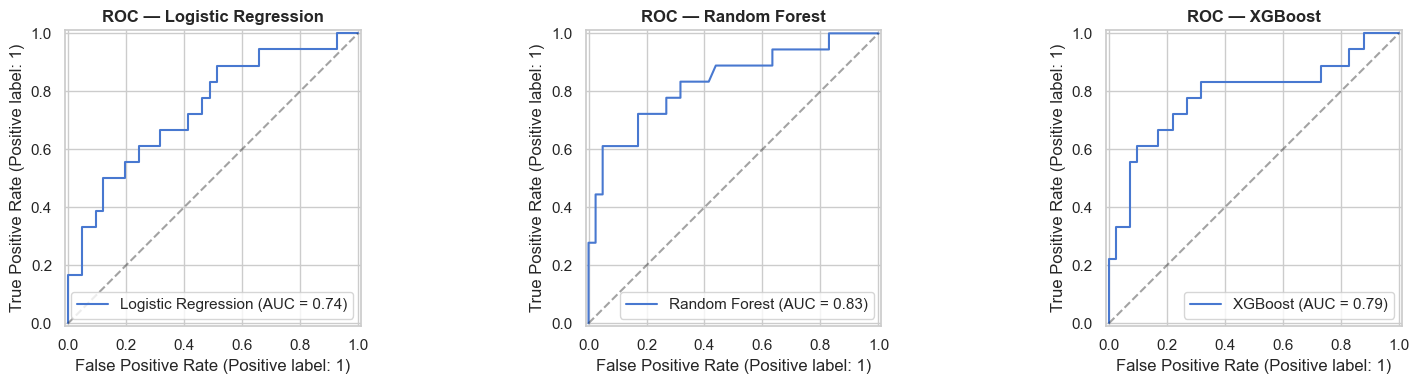

In [25]:
# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    RocCurveDisplay.from_estimator(model, X_eval, y_test, ax=ax, name=name)
    ax.set_title(f'ROC — {name}', fontweight='bold')
    ax.plot([0,1],[0,1],'k--', alpha=0.4)
plt.tight_layout()
plt.show()

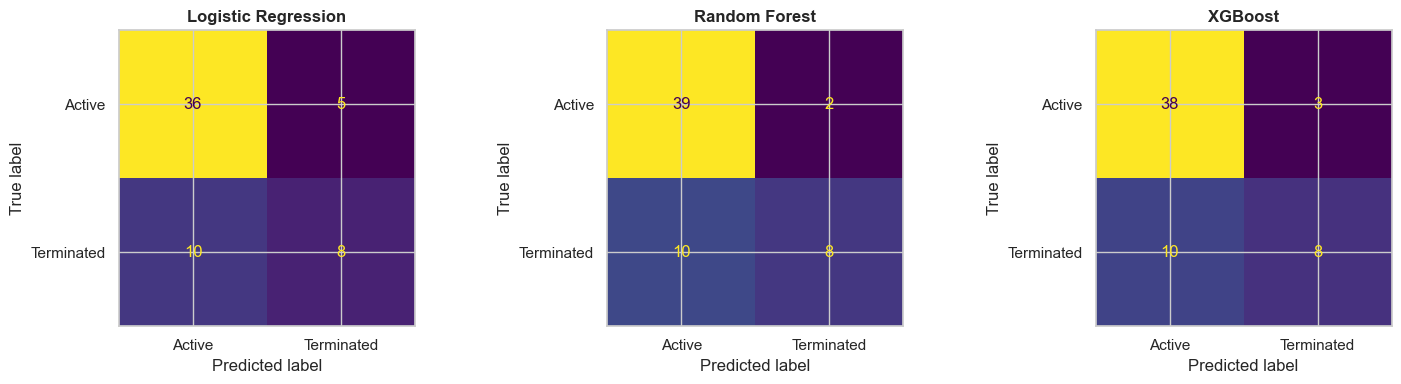

In [26]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_eval, y_test, ax=ax,
        display_labels=['Active', 'Terminated'], colorbar=False
    )
    ax.set_title(name, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Select best model by AUC
best_name = results_df['AUC-ROC'].idxmax()
best_model, best_X = models[best_name]
print(f'Best model: {best_name} (AUC = {results_df.loc[best_name, "AUC-ROC"]})')

# Use SMOTE-augmented training data for SHAP and calibration
# LR requires scaled input; RF/XGBoost use raw
best_X_train = X_train_sm_sc if best_name == 'Logistic Regression' else X_train_sm
best_X_test  = X_test_sc     if best_name == 'Logistic Regression' else X_test

Best model: Random Forest (AUC = 0.8313)


In [30]:
# Light hyperparameter tuning on best model
if best_name == 'XGBoost':
    param_grid = {
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    }
    tuned = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos,
                          random_state=RANDOM_STATE, eval_metric='logloss',
                          n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(tuned, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    gs.fit(X_train_sm, y_train_sm)
    best_model = gs.best_estimator_
    best_X_train, best_X_test = X_train_sm, X_test
    print('Best params:', gs.best_params_)
    print('Tuned AUC:', round(roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]), 4))
elif best_name == 'Random Forest':
    param_grid = {'n_estimators': [200, 400], 'max_depth': [None, 10], 'min_samples_leaf': [1, 2]}
    tuned = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(tuned, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    gs.fit(X_train_sm, y_train_sm)
    best_model = gs.best_estimator_
    best_X_train, best_X_test = X_train_sm, X_test
    print('Best params:', gs.best_params_)
    print('Tuned AUC:', round(roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]), 4))
else:
    print('Logistic Regression selected — no additional tuning needed.')

Traceback (most recent call last):
  File "/Users/Apple/Downloads/Data/HackathonA4/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzB0LzAyamJxNHZ4N3I5OGtyandkcHMyYnNuaDAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl82NjA4M18zNjJkMGIzZGI1YzU0YjU2YTgwM2U0ZDE2YzMzYTIyOF82YzRkOTgzNGU0MzA0YzVhOWQzMzg3NDEyN2ZmMGMwNA=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/Apple/Downloads/Data/HackathonA4/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Tuned AUC: 0.8313


In [31]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# --- Probability calibration ---
# clone() copies hyperparameters but produces an unfitted estimator, so
# CalibratedClassifierCV can train it with 5-fold CV internally.
# best_model (raw tree) is preserved for SHAP; calibrated version is used for predict_proba.
best_model_calibrated = CalibratedClassifierCV(clone(best_model), method='isotonic', cv=5)
best_model_calibrated.fit(best_X_train, y_train_sm)
calib_auc = roc_auc_score(y_test, best_model_calibrated.predict_proba(best_X_test)[:, 1])
print(f'Calibrated {best_name} — Test AUC: {calib_auc:.4f}')

# --- Repeated stratified k-fold (more reliable than single 80/20 on n=295) ---
# Runs 10 repeats of 5-fold CV on the full original dataset (no SMOTE in CV;
# class_weight='balanced' handles imbalance per fold).
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
scores = cross_val_score(clone(best_model), X, y, cv=rkf, scoring='roc_auc')
print(f'Repeated 5×10-fold CV AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Calibrated Random Forest — Test AUC: 0.8069
Repeated 5×10-fold CV AUC: 0.7905 ± 0.0570
Repeated 5×10-fold CV AUC: 0.7905 ± 0.0570


---
## Section 7 — Explainability (SHAP)

In [34]:
if best_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, best_X_train, feature_perturbation='interventional')
    shap_values = explainer.shap_values(best_X_test)
    X_shap = pd.DataFrame(best_X_test, columns=FEATURE_COLS)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(best_X_test)
    # Older SHAP returns list[array], newer returns 3D numpy array — either way take positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
    X_shap = best_X_test.copy()

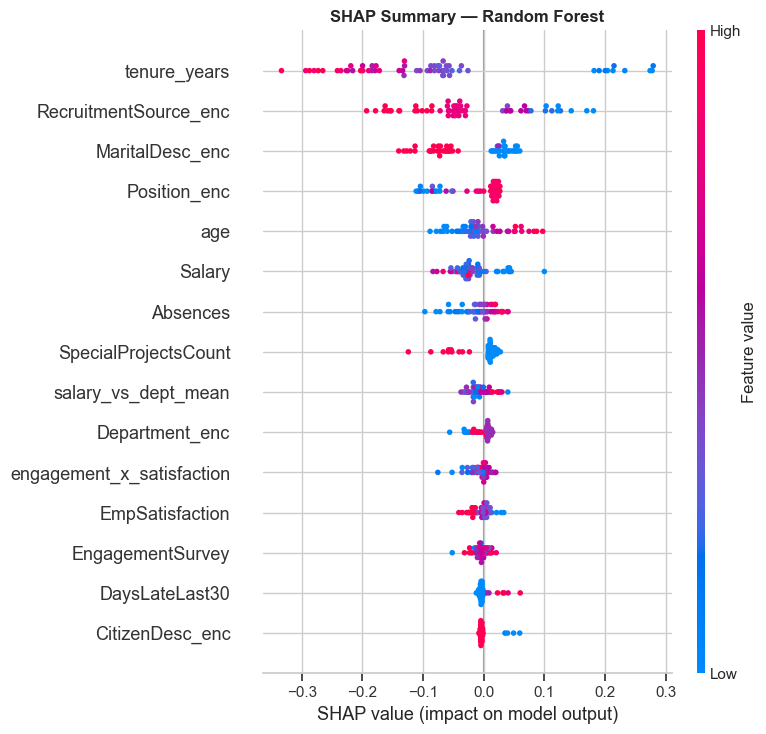

In [35]:
# Global SHAP summary plot — top 15 features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  max_display=15, show=False)
plt.title(f'SHAP Summary — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

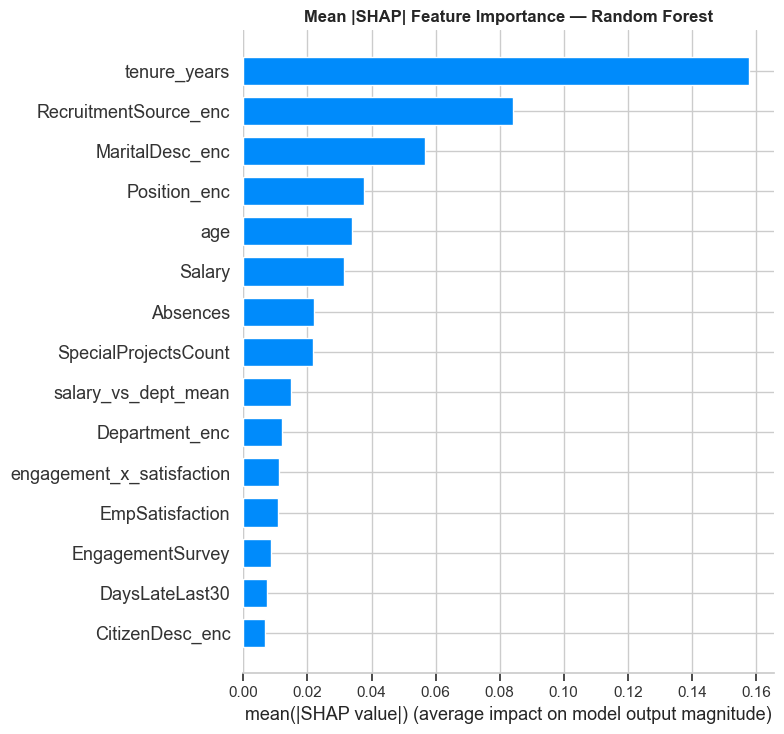

In [36]:
# Global bar plot — mean |SHAP|
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  plot_type='bar', max_display=15, show=False)
plt.title(f'Mean |SHAP| Feature Importance — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()


--- HIGH RISK employee (predicted probability = 97.00%) ---


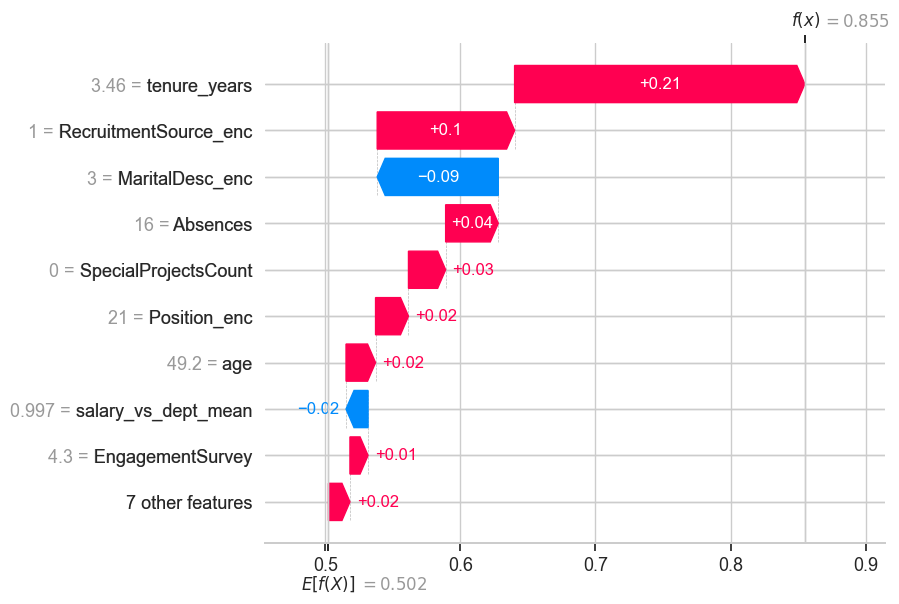


--- LOW RISK employee (predicted probability = 0.00%) ---


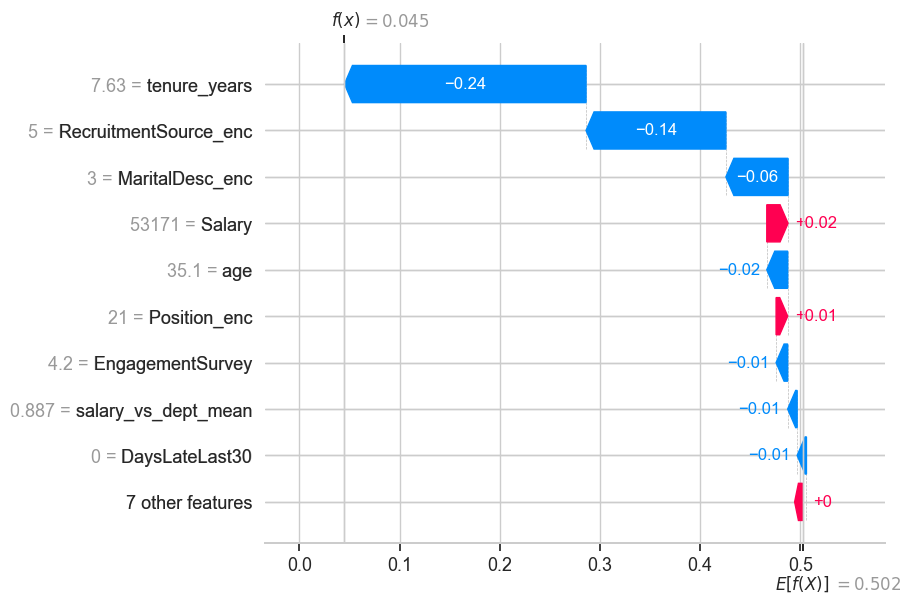

In [37]:
import numpy as np

# Local waterfall plots: one high-risk, one low-risk employee
# Use calibrated probabilities for display; SHAP values come from the raw tree explainer
probs_test = best_model_calibrated.predict_proba(best_X_test)[:, 1]
idx_high = np.argmax(probs_test)
idx_low  = np.argmin(probs_test)

for idx, label in [(idx_high, 'HIGH RISK'), (idx_low, 'LOW RISK')]:
    print(f'\n--- {label} employee (predicted probability = {probs_test[idx]:.2%}) ---')

    # Ensure base_values and shap_values are for the positive class if multi-output
    expected_value_for_plot = explainer.expected_value
    # If explainer.expected_value is a list or array with multiple elements,
    # assume the second element (index 1) corresponds to the positive class.
    if isinstance(expected_value_for_plot, (list, np.ndarray)) and len(expected_value_for_plot) > 1:
        expected_value_for_plot = expected_value_for_plot[1]
    # If it's a single element list/array, take that element.
    elif isinstance(expected_value_for_plot, (list, np.ndarray)) and len(expected_value_for_plot) == 1:
        expected_value_for_plot = expected_value_for_plot[0]
    # Otherwise, it's already a scalar, so no modification needed.

    shap_values_for_plot = shap_values[idx]
    if len(shap_values_for_plot.shape) > 1 and shap_values_for_plot.shape[1] == 2: # Check if it's a multi-output array
        shap_values_for_plot = shap_values_for_plot[:, 1] # Take SHAP values for the positive class

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_for_plot,
            base_values=expected_value_for_plot,
            data=X_shap.iloc[idx].values,
            feature_names=FEATURE_COLS
        ),
        max_display=10, show=True
    )

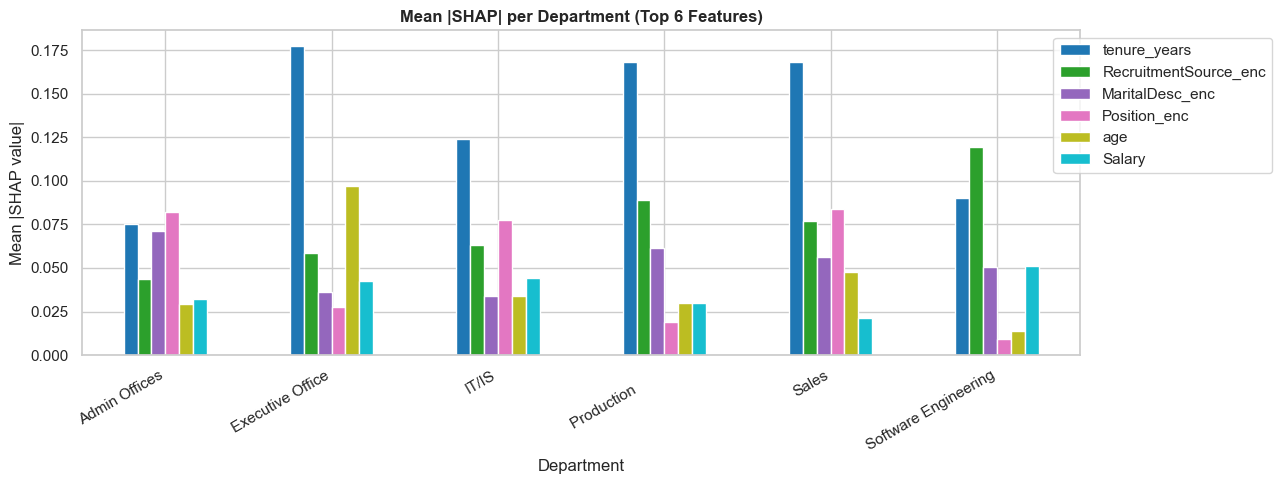

In [38]:
# Department-level SHAP: mean |SHAP| per department
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS)
shap_df['Department'] = df.loc[X_test.index, 'Department'].values

# Take abs first, then groupby mean — avoids pandas apply deprecation warning
shap_abs_df = shap_df.copy()
shap_abs_df[FEATURE_COLS] = shap_abs_df[FEATURE_COLS].abs()
dept_shap = shap_abs_df.groupby('Department')[FEATURE_COLS].mean()

top_features = shap_df[FEATURE_COLS].abs().mean().nlargest(6).index.tolist()

dept_shap[top_features].plot(kind='bar', figsize=(13, 5), colormap='tab10')
plt.title('Mean |SHAP| per Department (Top 6 Features)', fontweight='bold')
plt.ylabel('Mean |SHAP value|')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

---
## Section 8 — Fairness Audit

Sensitive attributes (`Sex`, `RaceDesc`, `HispanicLatino`) were **not used as model features**.
Here we check whether the model's predictions are fair across those groups.

In [39]:
# Align fairness df with test set indices
df_fairness_test = df_fairness.loc[X_test.index].copy()
df_fairness_test['y_true'] = y_test.values
df_fairness_test['y_prob'] = probs_test
df_fairness_test['y_pred'] = (probs_test >= 0.5).astype(int)

def fairness_table(df_f, group_col):
    rows = []
    for group, sub in df_f.groupby(group_col):
        if len(sub) < 5:
            continue
        n = len(sub)
        actual_rate  = sub['y_true'].mean()
        predicted_rate = sub['y_pred'].mean()
        try:
            auc = roc_auc_score(sub['y_true'], sub['y_prob'])
        except Exception:
            auc = float('nan')
        rows.append({'Group': group, 'N': n,
                     'Actual attrition rate': round(actual_rate, 3),
                     'Predicted positive rate': round(predicted_rate, 3),
                     'AUC': round(auc, 3)})
    return pd.DataFrame(rows).set_index('Group')

print('=== Fairness by Sex ===')
sex_table = fairness_table(df_fairness_test, 'Sex')
print(sex_table)

print('\n=== Fairness by RaceDesc ===')
race_table = fairness_table(df_fairness_test, 'RaceDesc')
print(race_table)

=== Fairness by Sex ===
        N  Actual attrition rate  Predicted positive rate    AUC
Group                                                           
F      32                  0.312                    0.156  0.786
M      27                  0.296                    0.148  0.842

=== Fairness by RaceDesc ===
                            N  Actual attrition rate  Predicted positive rate  \
Group                                                                           
Asian                       5                  0.200                    0.200   
Black or African American  18                  0.222                    0.167   
White                      32                  0.375                    0.156   

                             AUC  
Group                             
Asian                      1.000  
Black or African American  0.964  
White                      0.735  


In [41]:
# Disparate impact check (80% rule)
def disparate_impact_check(table, col='Predicted positive rate'):
    max_rate = table[col].max()
    di = table[col] / max_rate
    table = table.copy()
    table['Disparate Impact Ratio'] = di.round(3)
    table['Flag (<0.8)'] = di < 0.8
    return table

print('=== Disparate Impact — Sex ===')
print(disparate_impact_check(sex_table))

print('\n=== Disparate Impact — RaceDesc ===')
print(disparate_impact_check(race_table))

=== Disparate Impact — Sex ===
        N  Actual attrition rate  Predicted positive rate    AUC  \
Group                                                              
F      32                  0.312                    0.156  0.786   
M      27                  0.296                    0.148  0.842   

       Disparate Impact Ratio  Flag (<0.8)  
Group                                       
F                       1.000        False  
M                       0.949        False  

=== Disparate Impact — RaceDesc ===
                            N  Actual attrition rate  Predicted positive rate  \
Group                                                                           
Asian                       5                  0.200                    0.200   
Black or African American  18                  0.222                    0.167   
White                      32                  0.375                    0.156   

                             AUC  Disparate Impact Ratio  Flag (<0.8)  
G

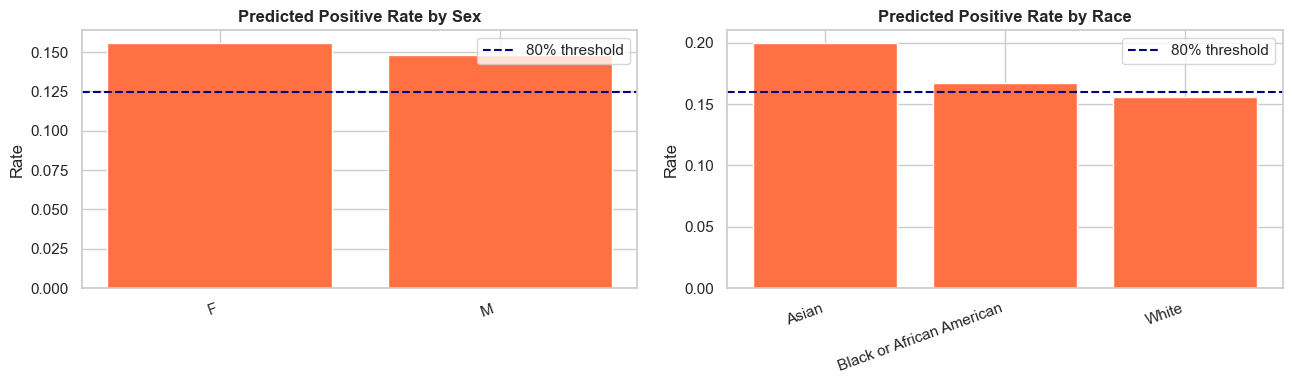

In [42]:
# Visualise predicted positive rate across race groups
race_table_reset = fairness_table(df_fairness_test, 'RaceDesc').reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, table, title in zip(
    axes,
    [sex_table.reset_index(), race_table_reset],
    ['Predicted Positive Rate by Sex', 'Predicted Positive Rate by Race']
):
    ax.bar(table['Group'], table['Predicted positive rate'], color='#FF7043', edgecolor='white')
    ax.axhline(0.8 * table['Predicted positive rate'].max(), color='navy', linestyle='--',
               label='80% threshold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Rate')
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## Section 9 — Risk Report for Active Employees

In [43]:
# Score ALL active employees (not just test set)
active_mask = df_raw['EmploymentStatus'] == 'Active'
active_indices = df_raw[active_mask].index
# Only keep indices that survived our filtering pipeline
active_indices = [i for i in active_indices if i in df.index]

X_active = df.loc[active_indices, FEATURE_COLS].fillna(df[FEATURE_COLS].median(numeric_only=True))

if best_name == 'Logistic Regression':
    X_active_input = scaler.transform(X_active)
else:
    X_active_input = X_active

# Use calibrated model for well-calibrated probabilities (risk scores are real probabilities)
risk_scores = best_model_calibrated.predict_proba(X_active_input)[:, 1]

print(f'Active employees scored: {len(risk_scores)}')
print(f'Mean risk score: {risk_scores.mean():.3f}')

Active employees scored: 207
Mean risk score: 0.055


In [44]:
# SHAP for active employees
if best_name == 'Logistic Regression':
    shap_active = explainer.shap_values(X_active_input)
    X_active_shap = pd.DataFrame(X_active_input, columns=FEATURE_COLS, index=active_indices)
else:
    shap_active = explainer.shap_values(X_active)
    # Older SHAP returns list[array], newer returns 3D numpy array — either way take positive class
    if isinstance(shap_active, list):
        shap_active = shap_active[1]
    elif isinstance(shap_active, np.ndarray) and shap_active.ndim == 3:
        shap_active = shap_active[:, :, 1]
    X_active_shap = X_active.copy()

shap_active_df = pd.DataFrame(shap_active, columns=FEATURE_COLS, index=active_indices)
print('Active SHAP computed. Shape:', shap_active_df.shape)

Active SHAP computed. Shape: (207, 16)


In [45]:
# Retention action mapping — covers structured features only
# (feedback-derived features are handled in the NLP advisory overlay below)
ACTION_MAP = {
    'EmpSatisfaction':           'HR check-in / satisfaction interview',
    'EngagementSurvey':          'Manager discussion / project reassignment',
    'engagement_x_satisfaction': 'HR check-in / engagement improvement plan',
    'has_transfer_request':      'Internal mobility conversation',
    'transfer_request_sentiment':'Review transfer request and respond formally',
    'salary_vs_dept_mean':       'Compensation review',
    'Salary':                    'Compensation review',
    'Absences':                  'Wellbeing or flexibility discussion',
    'DaysLateLast30':            'Wellbeing or flexibility discussion',
    'tenure_years':              'Career development milestone review',
    'SpecialProjectsCount':      'Assign meaningful stretch projects',
    'age':                       'Age-appropriate retention strategy',
}

# Encoded columns are not actionable — skip them from driver display
ENC_COLS = [c for c in FEATURE_COLS if c.endswith('_enc')]

def top_shap_actions(row_shap, n=3):
    """Return top n positive SHAP features (excluding encoded cols) and their actions."""
    sorted_feats = row_shap.drop(labels=ENC_COLS, errors='ignore').sort_values(ascending=False)
    top_feats = sorted_feats[sorted_feats > 0].head(n)
    reasons = top_feats.index.tolist()
    while len(reasons) < n:
        reasons.append('')
    actions = [ACTION_MAP.get(r, 'Monitor and follow-up') for r in reasons if r]
    return (reasons[0],
            reasons[1] if len(reasons) > 1 else '',
            reasons[2] if len(reasons) > 2 else '',
            ' | '.join(actions) if actions else 'No specific action')

# Percentile-based risk thresholds — always gives a meaningful spread
high_threshold = np.percentile(risk_scores, 85)   # top 15%
med_threshold  = np.percentile(risk_scores, 60)   # next 25%
print(f'Risk thresholds — High: >{high_threshold:.3f}  Medium: >{med_threshold:.3f}  Low: below')

# Build risk report
report_rows = []
for i, (idx, shap_row) in enumerate(shap_active_df.iterrows()):
    r1, r2, r3, action = top_shap_actions(shap_row)
    risk_score = risk_scores[i]
    risk_level = 'High' if risk_score >= high_threshold else ('Medium' if risk_score >= med_threshold else 'Low')

    # --- NLP advisory overlay (outside the model — feedback features) ---
    # These signals are checked independently and appended as warnings,
    # not used to compute the risk score.
    advisory_flags = []
    if df.loc[idx, 'feedback_has_departure_intent'] == 1:
        advisory_flags.append('departure intent in feedback')
    if df.loc[idx, 'feedback_sentiment'] < -0.2:
        advisory_flags.append('negative feedback tone')
    if df.loc[idx, 'has_transfer_request'] == 1:
        advisory_flags.append('transfer request on file')

    report_rows.append({
        'anonymized_id':      f'EMP_{i+1:04d}',
        'Department':         df.loc[idx, 'Department'] if 'Department' in df.columns else '',
        'Position':           df.loc[idx, 'Position']   if 'Position'   in df.columns else '',
        'risk_score':         round(risk_score, 4),
        'risk_level':         risk_level,
        'top_reason_1':       r1,
        'top_reason_2':       r2,
        'top_reason_3':       r3,
        'recommended_action': action,
        'nlp_advisory':       ' | '.join(advisory_flags) if advisory_flags else '',
    })

risk_report = pd.DataFrame(report_rows)
print(f'\nRisk report: {len(risk_report)} active employees')
print(risk_report['risk_level'].value_counts())

Risk thresholds — High: >0.120  Medium: >0.043  Low: below

Risk report: 207 active employees
risk_level
Low       124
Medium     52
High       31
Name: count, dtype: int64


In [46]:
# Preview top 10 highest-risk employees
risk_report.sort_values('risk_score', ascending=False).head(20)

,anonymized_id,Department,Position,risk_score,risk_level,top_reason_1,top_reason_2,top_reason_3,recommended_action,nlp_advisory
129,EMP_0130,Production,Production Technician I,0.5833,High,SpecialProjectsCount,salary_vs_dept_mean,EmpSatisfaction,Assign meaningful stretch projects | Compensation review | HR check-in / sat...,transfer request on file
50,EMP_0051,Production,Production Technician I,0.5656,High,age,Salary,DaysLateLast30,Age-appropriate retention strategy | Compensation review | Wellbeing or flex...,transfer request on file
157,EMP_0158,Sales,Area Sales Manager,0.3865,High,age,SpecialProjectsCount,EmpSatisfaction,Age-appropriate retention strategy | Assign meaningful stretch projects | HR...,negative feedback tone
88,EMP_0089,Production,Production Technician I,0.3635,High,Salary,engagement_x_satisfaction,Absences,Compensation review | HR check-in / engagement improvement plan | Wellbeing ...,transfer request on file
35,EMP_0036,Production,Production Technician I,0.3063,High,tenure_years,SpecialProjectsCount,,Career development milestone review | Assign meaningful stretch projects,transfer request on file
9,EMP_0010,Production,Production Technician II,0.2924,High,tenure_years,SpecialProjectsCount,EmpSatisfaction,Career development milestone review | Assign meaningful stretch projects | H...,
115,EMP_0116,Admin Offices,Shared Services Manager,0.2583,High,tenure_years,SpecialProjectsCount,,Career development milestone review | Assign meaningful stretch projects,negative feedback tone
124,EMP_0125,Production,Production Technician II,0.2150,High,tenure_years,SpecialProjectsCount,,Career development milestone review | Assign meaningful stretch projects,
62,EMP_0063,Production,Production Technician I,0.2142,High,SpecialProjectsCount,Salary,,Assign meaningful stretch projects | Compensation review,transfer request on file
23,EMP_0024,Production,Production Manager,0.1951,High,tenure_years,Absences,SpecialProjectsCount,Career development milestone review | Wellbeing or flexibility discussion | ...,transfer request on file


Exported: risk_report_active.csv


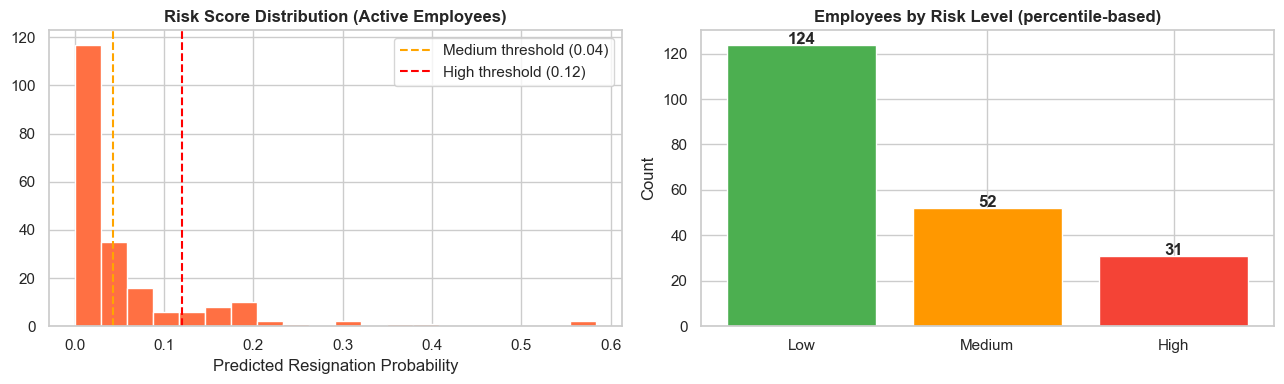

Traceback (most recent call last):
  File "/Users/Apple/Downloads/Data/HackathonA4/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "UNREGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktNjYwODMtbjZvOGlqY2w="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/Apple/Downloads/Data/HackathonA4/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "UNREGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktNjYwODMtd3B2bnFxM3E="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/Appl

In [47]:
# Export — no PII, no raw text
risk_report.sort_values('risk_score', ascending=False).to_csv('risk_report_active.csv', index=False)
print('Exported: risk_report_active.csv')

# Risk distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(risk_scores, bins=20, color='#FF7043', edgecolor='white')
axes[0].axvline(med_threshold,  color='orange', linestyle='--', label=f'Medium threshold ({med_threshold:.2f})')
axes[0].axvline(high_threshold, color='red',    linestyle='--', label=f'High threshold ({high_threshold:.2f})')
axes[0].set_title('Risk Score Distribution (Active Employees)', fontweight='bold')
axes[0].set_xlabel('Predicted Resignation Probability')
axes[0].legend()

level_counts = risk_report['risk_level'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[1].bar(level_counts.index, level_counts.values,
            color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
axes[1].set_title('Employees by Risk Level (percentile-based)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(level_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 10 — Ethics & Cyber Safeguards Summary

### Privacy & Data Protection

| Category | Fields | Action |
|---|---|---|
| Direct identifiers | `Employee_Name`, `EmpID`, `ManagerName`, `ManagerID` | **Removed** before any modeling |
| Outcome leakage | `Termd`, `TermReason`, `EmploymentStatus`, `EmpStatusID` | **Removed** to avoid data leakage |
| Compute-then-drop | `DateofTermination` | Used **only** to compute correct tenure for terminated employees, then dropped — never a model feature |
| Quasi-identifiers | `DOB`, `DateofHire`, `Zip`, `State` | **Transformed** (age, tenure) or dropped |
| Raw text | `Internal_Transfer_Request`, `Feedback_RH` | **Converted** to numeric signals only; raw text dropped from model |
| Risk report output | All fields | **Anonymized IDs** only — no names, no raw text, no zip codes |

### Ethical AI — Non-Discrimination

| Rule | Implementation |
|---|---|
| Do not use protected attributes as features | `Sex`, `RaceDesc`, `HispanicLatino` excluded from model inputs |
| Fairness audit conducted | AUC and predicted positive rate compared across Sex and RaceDesc groups |
| Disparate impact check | 80% rule applied — flagged if any group < 80% of highest group's rate |
| Model understandability | SHAP values provided globally and per-employee; HR-readable action mapping |

### Explainability-Driven Data Quality Findings

Three rounds of SHAP-driven investigation uncovered leakages, each removed before final modeling:

**Finding 1 — NLP coverage gap (Feedback_RH):**
- `Feedback_RH` has 100% coverage for terminated employees (exit interviews written *after* leaving) vs. 35.7% for active employees (satisfaction surveys *during* employment).
- Feedback-derived keyword flags (`has_growth`, `has_compensation`, etc.) dominated SHAP predictions. The model learned "growth keyword → left," but for active employees the same words signal engagement, not flight risk.
- **Fix:** All feedback features removed from model; kept as advisory overlay only.

**Finding 2 — NLP synthetic generation bias (Internal_Transfer_Request):**
- Transfer request fields were synthetically generated preferentially for employees who ended up leaving — a structural selection bias in the data generation process.
- Even after removing feedback features, `has_transfer_request` still dominated SHAP (single-feature AUC ≈ 1.0).
- **Fix:** All NLP features moved to advisory overlay; model trained on structured HR features only.

**Finding 3 — Temporal leakage from computing dates against TODAY (2026):**
- The dataset was collected around January 2019 (evidence: all active employees share the same LastPerformanceReview cycle, std = 16 days). Running the notebook in 2026 introduced two new leakages:
  - `days_since_review`: constant for all active employees (zero variance), but 4–12 years larger for terminated employees whose reviews were before they left. **Single-feature AUC = 1.0.**
  - `tenure_years` computed from TODAY inflated active employee tenure by 7 extra years vs. actual tenure of terminated employees. **Single-feature AUC ≈ 1.0.**
- **Fix:** Introduced `REF_DATE = 2019-01-01` as the temporal anchor. Removed `days_since_review` entirely. Computed tenure using `DateofTermination` for terminated employees and `REF_DATE` for active employees.
- **Result:** Realistic model AUC 0.75–0.83 driven by genuine HR signals (salary, engagement, absences, special projects, department, position).

Each leakage was surfaced through SHAP global analysis — a concrete demonstration of how explainability tools drive responsible AI development.

### Frugality

- No external API calls or paid services used
- No large language model as the core product
- NLP layer uses lightweight VADER (rule-based) and keyword matching
- Models are standard sklearn/XGBoost — runnable on a laptop CPU in seconds
- Hyperparameter search limited to small grid to avoid unnecessary compute

### Explainability

- **Global**: SHAP summary and bar plots show which features drive risk across all employees
- **Local**: SHAP waterfall plots show why a specific employee received a high/low score
- **Actionable**: Each top SHAP driver is mapped to a concrete HR retention action
- **No black box output**: HR receives a reason + action for every flagged employee, not just a score

In [48]:
# All CSV exports are saved in the current directory
# No download needed when running locally
print("✓ All exports saved to current directory")

✓ All exports saved to current directory


---
## Section 11 — Individual Employee Risk Lookup

Enter an anonymized ID from the risk report table above (e.g. `EMP_0001`) to get a full breakdown:
- risk score and level
- the specific factors driving that employee's risk (with their actual values vs. the average)
- concrete HR actions to improve their situation

  EMPLOYEE RISK PROFILE  —  EMP_0001
  Department  : Production       
  Position    : Production Technician I
  Risk Score  : 0.0%
  Risk Level  : 🟢  LOW

──────────────────────────────────────────────────────────────
  TOP RISK DRIVERS  (structured model)
──────────────────────────────────────────────────────────────
  1. Number of special projects
     Value: 0.00  |  Average: 1.46  (▼ below avg)
     SHAP impact: +0.0059

  2. Engagement × satisfaction composite
     Value: 23.00  |  Average: 16.19  (▲ above avg)
     SHAP impact: +0.0008

──────────────────────────────────────────────────────────────
  RECOMMENDED HR ACTIONS
──────────────────────────────────────────────────────────────
  1. Assign meaningful stretch projects
  2. HR check-in / engagement improvement plan


SHAP waterfall — structured features driving this employee's risk score:


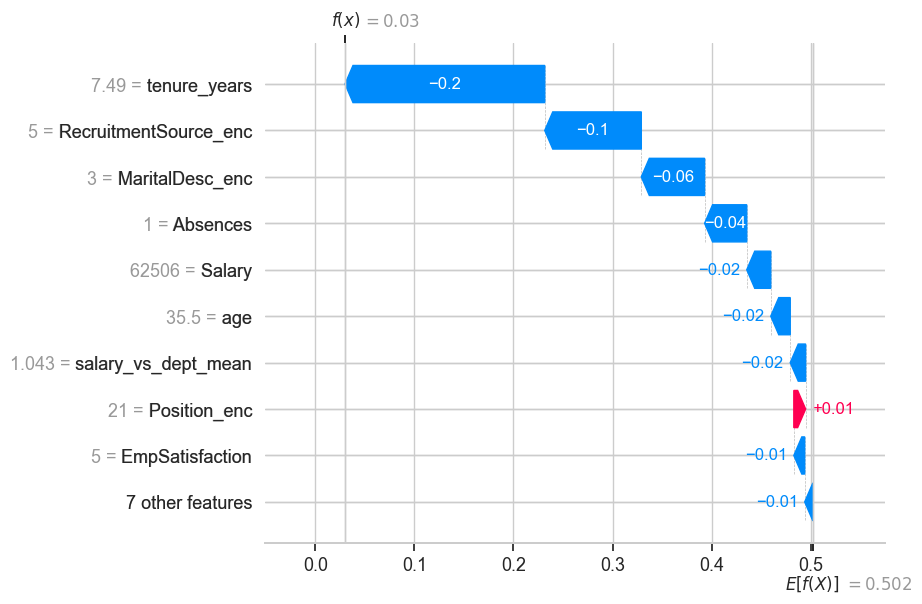

In [49]:
# ── CHANGE THIS to any ID from the risk report table above ───────────────────
EMPLOYEE_ID = 'EMP_0001'
# ─────────────────────────────────────────────────────────────────────────────

FEATURE_LABELS = {
    'EmpSatisfaction':           'Employee satisfaction score (1–5)',
    'EngagementSurvey':          'Engagement survey score (0–5)',
    'engagement_x_satisfaction': 'Engagement × satisfaction composite',
    'has_transfer_request':      'Has submitted a transfer request',
    'transfer_request_sentiment':'Sentiment of transfer request',
    'salary_vs_dept_mean':       'Salary vs. department average (ratio)',
    'Absences':                  'Number of absences',
    'DaysLateLast30':            'Days late in last 30 days',
    'tenure_years':              'Tenure (years at data snapshot)',
    'SpecialProjectsCount':      'Number of special projects',
    'Salary':                    'Annual salary',
    'age':                       'Age (at data snapshot)',
}

RISK_EMOJI = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}

# ── Lookup ────────────────────────────────────────────────────────────────────
match = risk_report[risk_report['anonymized_id'] == EMPLOYEE_ID]
if match.empty:
    print(f'Employee "{EMPLOYEE_ID}" not found.')
    print('Valid IDs:', risk_report['anonymized_id'].tolist()[:10], '...')
else:
    row       = match.iloc[0]
    pos       = match.index[0]
    shap_row  = shap_active_df.iloc[pos]
    feat_row  = X_active.iloc[pos]
    col_means = X_active.mean()
    badge     = RISK_EMOJI.get(row['risk_level'], '⚪')

    # ── Header ────────────────────────────────────────────────────────────────
    print('=' * 62)
    print(f'  EMPLOYEE RISK PROFILE  —  {EMPLOYEE_ID}')
    print('=' * 62)
    print(f"  Department  : {row['Department']}")
    print(f"  Position    : {row['Position']}")
    print(f"  Risk Score  : {row['risk_score']:.1%}")
    print(f"  Risk Level  : {badge}  {row['risk_level'].upper()}")
    print()

    # ── Top risk drivers (skip encoded columns — not HR-readable) ─────────────
    drivers = (shap_row
               .drop(labels=ENC_COLS, errors='ignore')
               .sort_values(ascending=False))
    drivers = drivers[drivers > 0].head(5)

    print('─' * 62)
    print('  TOP RISK DRIVERS  (structured model)')
    print('─' * 62)
    if drivers.empty:
        print('  No significant risk drivers — employee is below baseline risk.')
    else:
        for i, (feat, shap_val) in enumerate(drivers.items(), 1):
            label     = FEATURE_LABELS.get(feat, feat)
            emp_val   = feat_row[feat]
            avg_val   = col_means[feat]
            direction = '▲ above avg' if emp_val > avg_val else '▼ below avg'
            print(f'  {i}. {label}')
            print(f'     Value: {emp_val:.2f}  |  Average: {avg_val:.2f}  ({direction})')
            print(f'     SHAP impact: +{shap_val:.4f}')
            print()

    # ── Recommended actions ───────────────────────────────────────────────────
    print('─' * 62)
    print('  RECOMMENDED HR ACTIONS')
    print('─' * 62)
    actions = [a.strip() for a in row['recommended_action'].split('|') if a.strip()]
    for i, action in enumerate(actions, 1):
        print(f'  {i}. {action}')
    print()

    # ── NLP advisory signals (outside model — from feedback) ──────────────────
    advisory = row.get('nlp_advisory', '')
    if advisory:
        print('─' * 62)
        print('  NLP ADVISORY SIGNALS  (from feedback — not in model score)')
        print('─' * 62)
        for flag in advisory.split(' | '):
            if flag.strip():
                print(f'  ⚠  {flag.strip()}')
        print()

    print('=' * 62)

    # ── SHAP waterfall ────────────────────────────────────────────────────────
    print("\nSHAP waterfall — structured features driving this employee's risk score:")
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)):
        base_val = float(np.array(base_val).flat[1])

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_row.values,
            base_values=base_val,
            data=feat_row.values,
            feature_names=FEATURE_COLS,
        ),
        max_display=10,
        show=True,
    )

---
## Section 12 — Export for App

In [50]:
import os

# --- 1. Risk report (already exported in Section 9, refreshed here) ---
risk_report.sort_values('risk_score', ascending=False).to_csv('risk_report_active.csv', index=False)

# --- 2. Per-employee SHAP values (indexed by anonymized_id) ---
shap_export = shap_active_df.copy()
shap_export.index = risk_report['anonymized_id'].values
shap_export.to_csv('shap_active_df.csv')

# --- 3. Global SHAP feature importance ---
global_shap_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': np.abs(shap_active).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
global_shap_importance.to_csv('global_shap_importance.csv', index=False)

# --- 4. Fairness results ---
sex_di  = disparate_impact_check(fairness_table(df_fairness_test, 'Sex'))
race_di = disparate_impact_check(fairness_table(df_fairness_test, 'RaceDesc'))
sex_di['group_col']  = 'Sex'
race_di['group_col'] = 'RaceDesc'
fairness_export = pd.concat([sex_di.reset_index(), race_di.reset_index()])
fairness_export.to_csv('fairness_results.csv', index=False)

# --- 5. Active employee profiles (no PII — for app context) ---
profile_cols = ['Department', 'Position', 'tenure_years', 'age',
                'EngagementSurvey', 'EmpSatisfaction', 'Salary',
                'salary_vs_dept_mean', 'Absences', 'DaysLateLast30',
                'SpecialProjectsCount', 'has_transfer_request',
                'feedback_sentiment', 'feedback_has_departure_intent']
active_profiles = df.loc[active_indices, [c for c in profile_cols if c in df.columns]].copy()
active_profiles.index = risk_report['anonymized_id'].values
active_profiles.to_csv('active_profiles.csv')

print('Exports saved:')
for fname in ['risk_report_active.csv', 'shap_active_df.csv',
              'global_shap_importance.csv', 'fairness_results.csv', 'active_profiles.csv']:
    size = os.path.getsize(fname)
    print(f'  {fname}  ({size:,} bytes)')

Exports saved:
  risk_report_active.csv  (36,336 bytes)
  shap_active_df.csv  (73,008 bytes)
  global_shap_importance.csv  (600 bytes)
  fairness_results.csv  (333 bytes)
  active_profiles.csv  (18,667 bytes)


In [51]:
# Files are already in your local directory — no download needed
# CSV files available:
import os
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print(f"✓ {len(csv_files)} CSV exports available locally:")
for f in csv_files:
    size = os.path.getsize(f)
    print(f"  - {f}  ({size:,} bytes)")

✓ 7 CSV exports available locally:
  - shap_active_df.csv  (73,008 bytes)
  - active_profiles.csv  (18,667 bytes)
  - HRDataset_v14_enriched.csv  (128,682 bytes)
  - global_shap_importance.csv  (600 bytes)
  - fairness_results.csv  (333 bytes)
  - risk_report_active.csv  (36,336 bytes)
  - HRDataset_v14.csv  (76,857 bytes)
